# Język Python w Analizie Danych
# Pandas
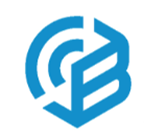
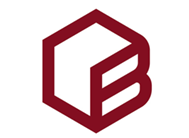
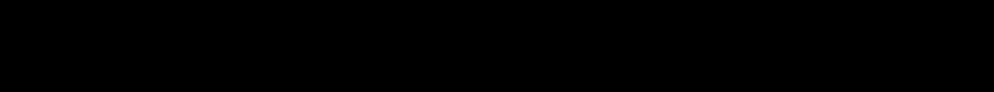
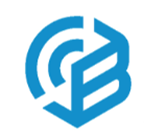

## Cel zajęć
- Poznanie zastosowania modułu `Pandas`.
- Ćwiczenie wykorzystania obiektów typu `Series`, `DataFrame` i `Index` w praktyce.
- Wykonanie zadańćwiczeniowych z wykorzystaniem modułu.

## Część teoretyczna

### Dokumentacja
- Pandas: https://pandas.pydata.org/docs/

In [5]:
# Import modułu
import pandas as pd

### Przykłady

In [6]:
# Tworzenie Series
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(type(s))
print(s)

<class 'pandas.Series'>
a    10
b    20
c    30
dtype: int64


In [7]:
# Tworzenie DataFrame
data = {
    "kol1": [1, 2, 3],
    "kol2": ["A", "B", "C"]
}
df = pd.DataFrame(data)

print(type(df))
print(df)

<class 'pandas.DataFrame'>
   kol1 kol2
0     1    A
1     2    B
2     3    C


In [9]:
# Odczyt i zapis plików CSV
df = pd.read_csv("data/example_data_pandas.csv")
print(df)
df.to_csv("data/example_results_pandas.csv", index=False)

      Imie       Nazwisko  Wiek     Miasto
0      Jan       Kowalski    23   Warszawa
1     Anna          Nowak    25     Kraków
2    Piotr     Wiśniewski    30     Gdańsk
3    Marek    Lewandowski    28    Wrocław
4    Jacek          Kowal    28  Bydgoszcz
5  Paulina          Nowak    31     Poznań
6   Tomasz  Tomaszkiewicz    24        NaN


In [12]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Imie      7 non-null      str  
 1   Nazwisko  7 non-null      str  
 2   Wiek      7 non-null      int64
 3   Miasto    6 non-null      str  
dtypes: int64(1), str(3)
memory usage: 356.0 bytes
None


### Zadanie 1
Stwórz obiekt typu `Series` z 10 losowymi liczbami i własnym indeksem. Wyświetl początkowe dane. Posortuj je rosnąco, a następnie wyświetl większe lub równe medianie.

In [17]:
# TODO: zadanie 1
import numpy as np

np.random.seed(0)
values = list(np.random.randint(0, 100, size=9)) + [127902]
s = pd.Series(values, index=[f'idx{i}' for i in range(10)])

print("Dane początkowe:")
print(s)
print("\nDane posortowane:")
print(s.sort_values())
print("\nMediana:", s.median())
print("\nElementy >= medianie:")
print(s[s >= s.median()])

Dane początkowe:
idx0        44
idx1        47
idx2        64
idx3        67
idx4        67
idx5         9
idx6        83
idx7        21
idx8        36
idx9    127902
dtype: int64

Dane posortowane:
idx5         9
idx7        21
idx8        36
idx0        44
idx1        47
idx2        64
idx4        67
idx3        67
idx6        83
idx9    127902
dtype: int64

Mediana: 55.5

Elementy >= medianie:
idx2        64
idx3        67
idx4        67
idx6        83
idx9    127902
dtype: int64


### Zadanie 2
Wczytaj dane z pliku `data_pandas.csv` i wyświetl pierwsze oraz ostatnie 5 wierszy, informacje o kolumnach i podstawowe statystyki opisowe

#### Kod źródłowy

In [18]:
 # TODO: zadanie 2

data_path = "data/data_pandas.csv"
df = pd.read_csv(data_path, parse_dates=True)

print('\nPierwsze 5 wierszy:')
print(df.head())
print('\nOstatnie 5 wierszy:')
print(df.tail())
print('\nInformacje o kolumnach:')
print(df.info())
print('\nPodstawowe statystyki opisowe:')
print(df.describe(include='all'))


Pierwsze 5 wierszy:
  index        date   value
0   gk9  2025-09-09   24.43
1   j5d  2025-06-16  223.46
2   hi4  2025-08-10  642.85
3   zfb  2025-04-05  617.85
4   gdi  2025-07-05  808.32

Ostatnie 5 wierszy:
   index        date   value
25   xjs  2025-07-21  319.92
26   k27  2025-06-19  980.27
27   zgy  2025-03-14  509.36
28   ke7  2025-02-26  222.33
29   t6h  2025-04-08  626.61

Informacje o DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   30 non-null     str    
 1   date    30 non-null     str    
 2   value   30 non-null     float64
dtypes: float64(1), str(2)
memory usage: 852.0 bytes
None

Podstawowe statystyki opisowe:
       index        date       value
count     30          30   30.000000
unique    30          27         NaN
top      gk9  2025-08-10         NaN
freq       1           2         NaN
mean     NaN         NaN  498.086333
std

### Zadanie 3
Na podstawie wczytanych danych:

a) wybierz kolumnę `value` i oblicz jej średnią,

b) wyświtl podzbiór danych spełniający warunek: wartość `value` większa niż średnia, data to dowolny dzień czerwca 2025

c) posortuje dane malejąco według wartości w kolumnie `value`
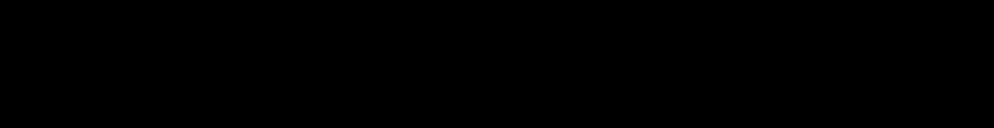
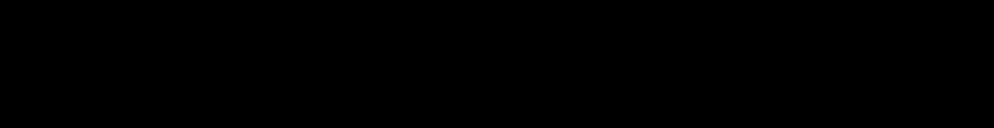

#### Kod źródłowy

In [19]:
mean = 0
# TODO: a)

mean = df['value'].mean()

print(mean)

498.08633333333347


In [21]:
filtered_data = 0
# TODO: b)

df['date'] = pd.to_datetime(df['date'])

filtered_data = df[(df['value'] > mean) &
                   (df['date'].dt.month == 6) &
                   (df['date'].dt.year == 2025)]

print(filtered_data)

   index       date   value
26   k27 2025-06-19  980.27


In [22]:
sorted_data = 0
# TODO: c)

sorted_data = df.sort_values(by='value', ascending=False)

print(sorted_data)

   index       date   value
22   040 2025-05-10  992.98
26   k27 2025-06-19  980.27
16   o6j 2025-07-07  912.86
21   w0y 2025-08-28  877.69
5    7bk 2025-08-29  862.32
6    d1o 2025-08-26  857.73
23   j4v 2025-04-22  834.87
4    gdi 2025-07-05  808.32
13   9k2 2025-09-11  785.88
14   uw7 2025-07-25  699.20
17   0wq 2025-04-17  685.94
9    t4y 2025-07-30  671.93
2    hi4 2025-08-10  642.85
29   t6h 2025-04-08  626.61
3    zfb 2025-04-05  617.85
27   zgy 2025-03-14  509.36
15   yi9 2025-02-19  383.61
24   rju 2025-05-16  343.95
25   xjs 2025-07-21  319.92
20   l9m 2025-08-10  228.85
8    c6p 2025-01-05  227.06
1    j5d 2025-06-16  223.46
28   ke7 2025-02-26  222.33
12   ol0 2025-05-30  180.30
10   mry 2025-09-27  151.91
19   umt 2025-07-25  128.89
7    ryu 2025-04-06  120.11
0    gk9 2025-09-09   24.43
18   bk7 2025-05-16   15.55
11   abt 2025-06-30    5.56


### Zadanie 4
Dodaj do wcześniej wczytanych danych kolumnę `Paid`. Zapisz w niej wartość `True` lub `False` jeśli data jest wcześniejsza niż 1.09.2025.

#### Kod źródłowy

In [25]:
# TODO: zadanie 4

df['Paid'] = df['date'] < pd.Timestamp('2025-09-01')

print(df)

   index       date   value   Paid
0    gk9 2025-09-09   24.43  False
1    j5d 2025-06-16  223.46   True
2    hi4 2025-08-10  642.85   True
3    zfb 2025-04-05  617.85   True
4    gdi 2025-07-05  808.32   True
5    7bk 2025-08-29  862.32   True
6    d1o 2025-08-26  857.73   True
7    ryu 2025-04-06  120.11   True
8    c6p 2025-01-05  227.06   True
9    t4y 2025-07-30  671.93   True
10   mry 2025-09-27  151.91  False
11   abt 2025-06-30    5.56   True
12   ol0 2025-05-30  180.30   True
13   9k2 2025-09-11  785.88  False
14   uw7 2025-07-25  699.20   True
15   yi9 2025-02-19  383.61   True
16   o6j 2025-07-07  912.86   True
17   0wq 2025-04-17  685.94   True
18   bk7 2025-05-16   15.55   True
19   umt 2025-07-25  128.89   True
20   l9m 2025-08-10  228.85   True
21   w0y 2025-08-28  877.69   True
22   040 2025-05-10  992.98   True
23   j4v 2025-04-22  834.87   True
24   rju 2025-05-16  343.95   True
25   xjs 2025-07-21  319.92   True
26   k27 2025-06-19  980.27   True
27   zgy 2025-03-14 

### Zadanie 5
Użyj metody `groupby` do pogrupowania danych wg daty sprzedaży. Policz sumę dla każdego miesiąca.

In [28]:
# TODO: Zadanie 5

monthly_sum = df.groupby(df['date'].dt.to_period('M'))['value'].sum()

print(monthly_sum)

date
2025-01     227.06
2025-02     605.94
2025-03     509.36
2025-04    2885.38
2025-05    1532.78
2025-06    1209.29
2025-07    3541.12
2025-08    3469.44
2025-09     962.22
Freq: M, Name: value, dtype: float64


### Zadanie 6
Utwórz dwa obiekty `Index`. Porównaj oba zbiory. Wypisz ich część wspólną oraz różnicę.

In [31]:
cp = 0
diff = 0
# TODO: Zadanie 6

idx1 = pd.Index([1, 2, 3, 4, 5])
idx2 = pd.Index([4, 5, 6, 7, 8])

cp = idx1.intersection(idx2)
diff = idx1.difference(idx2)
diff2 = idx2.difference(idx1)

print(f"Część wspólna: {cp}")
print(f"Różnica: {diff}")

cp2 = idx2.intersection(idx1)
diff2 = idx2.difference(idx1)
print(f"Część wspólna (odwrotnie): {cp2}")
print(f"Różnica (odwrotnie): {diff2}")

Część wspólna: Index([4, 5], dtype='int64')
Różnica: Index([1, 2, 3], dtype='int64')
Część wspólna (odwrotnie): Index([4, 5], dtype='int64')
Różnica (odwrotnie): Index([6, 7, 8], dtype='int64')


### Sprawozdanie

Sprawozdanie powinno zawierać:
- plik notatnika `.ipynb` z rozwiązaniami zadań,
- opis stworzonych rozwiązań,
- zrzuty ekranu potwierdzające poprawne działanie kodu lub widoczne wyniki uruchomienia komórek z notatnika jupyter,
- wnioski,
- (opcjonalnie) uwagi i sugestie dotyczące instrukcji i treści laboratorium,
- (opcjonalnie) bibliografię
Sprawozdanie dopuszczalne tylko w formacie `.pdf` lub `.tex` lub `.ipynb`.